<a href="https://colab.research.google.com/github/SNaqvi7/Artificial-Intelligence-/blob/main/Helmet_Detection_by_Using_CNN_Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

To Built The Model:
*  InPut Layer
* Base Model CNN
* Dense Layer
* Activation
* Output Layer
* Compile Model **bold text**
* Predict Model


# CNN classifier

Kaggle Helmet Dataset
        ↓
Read XML annotations
        ↓
Extract bounding boxes
        ↓
Crop helmet/head regions
        ↓
Assign labels
        ↓
With Helmet / Without Helmet
        ↓
Train / Validation / Test split
        ↓
CNN
        ↓
Accuracy / Precision / Recall / F1
        ↓
Confusion Matrix

# Dowoload Libraries

In [1]:
# ==============================
# 2. IMPORT ALL LIBRARIES
# ==============================

import os
import glob
import shutil
import random
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd

import cv2
from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from tensorflow.keras.optimizers import Adam

print("TensorFlow version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

TensorFlow version: 2.21.0
Num GPUs Available: 0


# Download the Kaggle dataset

In [3]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "andrewmvd/helmet-detection"
)

print("Dataset downloaded to:")
print(dataset_path)

Using Colab cache for faster access to the 'helmet-detection' dataset.
Dataset downloaded to:
/kaggle/input/helmet-detection


# Examine the dataset

In [4]:
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")

    if level < 2:
        for file in files[:10]:
            print(f"{indent}    {file}")

helmet-detection/
    annotations/
        BikesHelmets338.xml
        BikesHelmets680.xml
        BikesHelmets62.xml
        BikesHelmets172.xml
        BikesHelmets622.xml
        BikesHelmets477.xml
        BikesHelmets488.xml
        BikesHelmets696.xml
        BikesHelmets71.xml
        BikesHelmets269.xml
    images/
        BikesHelmets719.png
        BikesHelmets219.png
        BikesHelmets18.png
        BikesHelmets283.png
        BikesHelmets277.png
        BikesHelmets76.png
        BikesHelmets88.png
        BikesHelmets430.png
        BikesHelmets40.png
        BikesHelmets190.png


# Find images and XML files automatically

In [9]:
# ============================================
# CELL 5 — FIND IMAGES AND XML FILES
# ============================================

image_extensions = [
    "*.jpg",
    "*.jpeg",
    "*.png",
    "*.JPG",
    "*.JPEG",
    "*.PNG"
]

image_files = []

for extension in image_extensions:
    image_files.extend(
        glob.glob(
            os.path.join(dataset_path, "**", extension),
            recursive=True
        )
    )

xml_files = glob.glob(
    os.path.join(dataset_path, "**", "*.xml"),
    recursive=True
)

print("Number of images:", len(image_files))
print("Number of XML files:", len(xml_files))

print("\nExample images:")
print(image_files[:5])

print("\nExample XML files:")
print(xml_files[:5])

Number of images: 764
Number of XML files: 764

Example images:
['/kaggle/input/helmet-detection/images/BikesHelmets719.png', '/kaggle/input/helmet-detection/images/BikesHelmets219.png', '/kaggle/input/helmet-detection/images/BikesHelmets18.png', '/kaggle/input/helmet-detection/images/BikesHelmets283.png', '/kaggle/input/helmet-detection/images/BikesHelmets277.png']

Example XML files:
['/kaggle/input/helmet-detection/annotations/BikesHelmets338.xml', '/kaggle/input/helmet-detection/annotations/BikesHelmets680.xml', '/kaggle/input/helmet-detection/annotations/BikesHelmets62.xml', '/kaggle/input/helmet-detection/annotations/BikesHelmets172.xml', '/kaggle/input/helmet-detection/annotations/BikesHelmets622.xml']


# Inspect the labels: With Helmet, Without Helmet


In [11]:
# ============================================
# CELL 7 — EXTRACT ALL LABEL NAMES
# ============================================

all_labels = []

for xml_file in xml_files:

    try:

        tree = ET.parse(xml_file)
        root = tree.getroot()

        for obj in root.findall("object"):

            name = obj.find("name")

            if name is not None:
                all_labels.append(
                    name.text.strip()
                )

    except Exception as e:
        print("Error:", xml_file, e)

unique_labels = sorted(set(all_labels))

print("Labels found:")
for label in unique_labels:
    print(label)

print("\nTotal objects:", len(all_labels))

Labels found:
With Helmet
Without Helmet

Total objects: 1451


# Create a label mapping:

In [12]:
print("Available labels:")
print(unique_labels)

Available labels:
['With Helmet', 'Without Helmet']


# AUTOMATIC LABEL MAPPING:

In [13]:
label_mapping = {
    "With Helmet": "helmet",
    "Without Helmet": "no_helmet"
}

# LABEL MAPPING: With Helmet, helmet, Without Helmet, no_helme

In [14]:
label_mapping = {}

for label in unique_labels:

    label_lower = label.lower().replace("_", " ").replace("-", " ")

    if "without" in label_lower and "helmet" in label_lower:
        label_mapping[label] = "no_helmet"

    elif "no" in label_lower and "helmet" in label_lower:
        label_mapping[label] = "no_helmet"

    elif "with" in label_lower and "helmet" in label_lower:
        label_mapping[label] = "helmet"

    elif label_lower == "helmet":
        label_mapping[label] = "helmet"

print("Label mapping:")
print(label_mapping)

Label mapping:
{'With Helmet': 'helmet', 'Without Helmet': 'no_helmet'}


Create Direction:helmet_cnn/
│
├── train/
│   ├── helmet/
│   └── no_helmet/
│
├── validation/
│   ├── helmet/
│   └── no_helmet/
│
└── test/
    ├── helmet/
    └── no_helmet/

# CREATE DATASET DIRECTORIES:

In [15]:
output_dir = "/content/helmet_cnn"

if os.path.exists(output_dir):
    shutil.rmtree(output_dir)

folders = [
    "train/helmet",
    "train/no_helmet",
    "validation/helmet",
    "validation/no_helmet",
    "test/helmet",
    "test/no_helmet"
]

for folder in folders:

    os.makedirs(
        os.path.join(output_dir, folder),
        exist_ok=True
    )

print("Directories created.")

Directories created.


# CREATE IMAGE LOOKUP:

In [16]:
image_lookup = {}

for image_file in image_files:

    filename = os.path.basename(image_file)

    # Store by complete filename
    image_lookup[filename] = image_file

    # Store without extension
    base_name = os.path.splitext(filename)[0]

    image_lookup[base_name] = image_file

print("Image lookup created.")
print("Entries:", len(image_lookup))

Image lookup created.
Entries: 1528


# Crop Images:

In [17]:
# ============================================
# CELL 11 — EXTRACT CROPS FROM XML
# ============================================

crop_records = []

crop_counter = 0

for xml_file in xml_files:

    try:

        tree = ET.parse(xml_file)
        root = tree.getroot()

        # Get image filename from XML
        filename_element = root.find("filename")

        image_path = None

        if filename_element is not None:

            filename = filename_element.text.strip()

            if filename in image_lookup:
                image_path = image_lookup[filename]

            else:

                base_name = os.path.splitext(filename)[0]

                if base_name in image_lookup:
                    image_path = image_lookup[base_name]

        # If filename lookup failed, use XML filename
        if image_path is None:

            xml_base = os.path.splitext(
                os.path.basename(xml_file)
            )[0]

            if xml_base in image_lookup:
                image_path = image_lookup[xml_base]

        if image_path is None:
            continue

        image = cv2.imread(image_path)

        if image is None:
            continue

        height, width = image.shape[:2]

        for obj in root.findall("object"):

            name_element = obj.find("name")

            if name_element is None:
                continue

            original_label = name_element.text.strip()

            if original_label not in label_mapping:
                continue

            class_name = label_mapping[original_label]

            bbox = obj.find("bndbox")

            if bbox is None:
                continue

            xmin = int(float(bbox.find("xmin").text))
            ymin = int(float(bbox.find("ymin").text))
            xmax = int(float(bbox.find("xmax").text))
            ymax = int(float(bbox.find("ymax").text))

            # Keep coordinates inside image
            xmin = max(0, min(xmin, width - 1))
            xmax = max(0, min(xmax, width))
            ymin = max(0, min(ymin, height - 1))
            ymax = max(0, min(ymax, height))

            # Make sure box is valid
            if xmax <= xmin or ymax <= ymin:
                continue

            crop = image[ymin:ymax, xmin:xmax]

            if crop.size == 0:
                continue

            crop_counter += 1

            crop_records.append({
                "crop_id": crop_counter,
                "image": image_path,
                "xml": xml_file,
                "original_label": original_label,
                "class": class_name,
                "xmin": xmin,
                "ymin": ymin,
                "xmax": xmax,
                "ymax": ymax
            })

    except Exception as e:

        print(
            "Error processing:",
            xml_file,
            e
        )

print("Total valid crops:", len(crop_records))

Total valid crops: 1451


# Convert records to DATAFRAME:
1) helmet
2) no_helmet

In [18]:
df = pd.DataFrame(crop_records)

print(df.head())

print("\nClass distribution:")
print(df["class"].value_counts())

print("\nTotal samples:")
print(len(df))

   crop_id                                              image  \
0        1  /kaggle/input/helmet-detection/images/BikesHel...   
1        2  /kaggle/input/helmet-detection/images/BikesHel...   
2        3  /kaggle/input/helmet-detection/images/BikesHel...   
3        4  /kaggle/input/helmet-detection/images/BikesHel...   
4        5  /kaggle/input/helmet-detection/images/BikesHel...   

                                                 xml  original_label  \
0  /kaggle/input/helmet-detection/annotations/Bik...  Without Helmet   
1  /kaggle/input/helmet-detection/annotations/Bik...  Without Helmet   
2  /kaggle/input/helmet-detection/annotations/Bik...     With Helmet   
3  /kaggle/input/helmet-detection/annotations/Bik...  Without Helmet   
4  /kaggle/input/helmet-detection/annotations/Bik...  Without Helmet   

       class  xmin  ymin  xmax  ymax  
0  no_helmet   102   158   125   190  
1  no_helmet   283   146   291   156  
2     helmet   167     0   226    57  
3  no_helmet   161  

# Visualize class distribution:

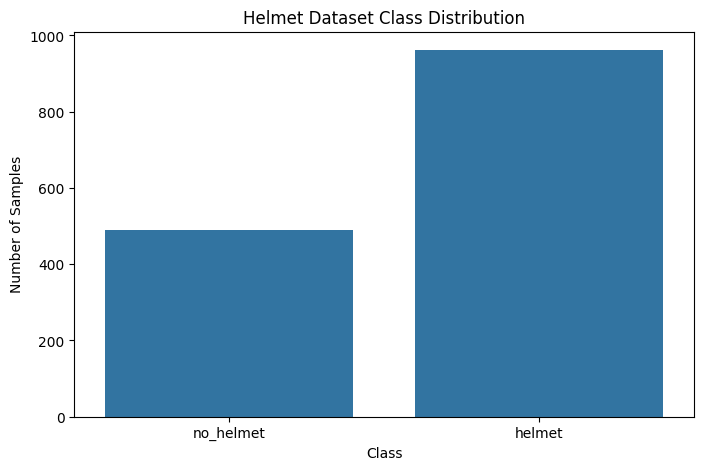

In [19]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="class"
)

plt.title("Helmet Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")

plt.show()

# Split dataset: TRAIN/VALIDATION/TEST SPLIT
70% training - 15% validation - 15% testing

In [20]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["class"]
)

validation_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["class"]
)

print("Training samples:", len(train_df))
print("Validation samples:", len(validation_df))
print("Testing samples:", len(test_df))

Training samples: 1015
Validation samples: 218
Testing samples: 218


# Save cropped images

In [21]:
def save_crops(dataframe, split_name):

    for _, row in dataframe.iterrows():

        image_path = row["image"]

        image = cv2.imread(image_path)

        if image is None:
            continue

        xmin = int(row["xmin"])
        ymin = int(row["ymin"])
        xmax = int(row["xmax"])
        ymax = int(row["ymax"])

        crop = image[ymin:ymax, xmin:xmax]

        if crop.size == 0:
            continue

        class_name = row["class"]

        output_folder = os.path.join(
            output_dir,
            split_name,
            class_name
        )

        os.makedirs(
            output_folder,
            exist_ok=True
        )

        filename = (
            f'{int(row["crop_id"])}_'
            f'{os.path.basename(image_path)}'
        )

        output_path = os.path.join(
            output_folder,
            filename
        )

        cv2.imwrite(
            output_path,
            crop
        )


save_crops(train_df, "train")
save_crops(validation_df, "validation")
save_crops(test_df, "test")

print("Cropped images saved successfully.")

Cropped images saved successfully.


# DISPLAY SAMPLE IMAGES:

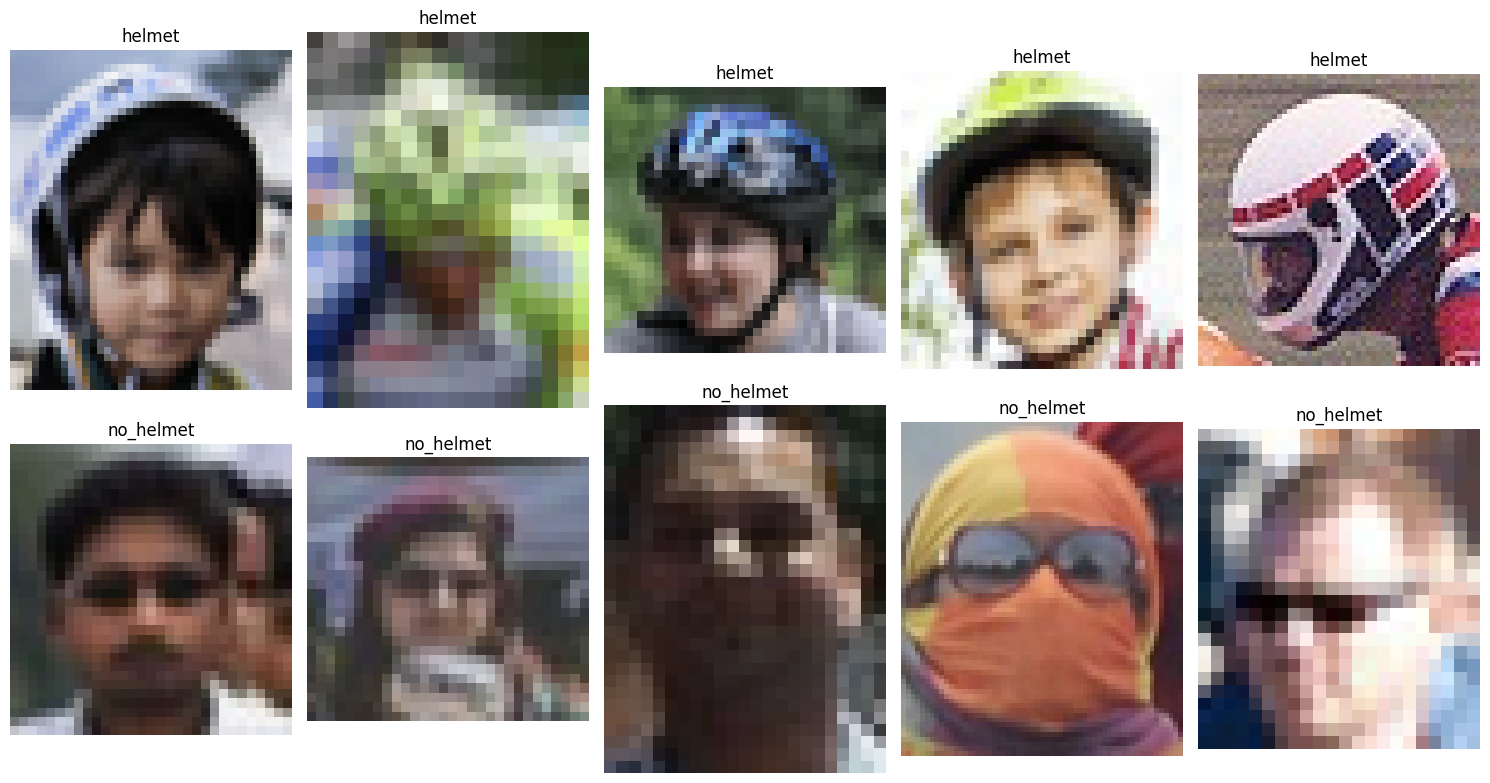

In [23]:
train_helmet = glob.glob(
    os.path.join(
        output_dir,
        "train",
        "helmet",
        "*"
    )
)

train_no_helmet = glob.glob(
    os.path.join(
        output_dir,
        "train",
        "no_helmet",
        "*"
    )
)

sample_images = (
    train_helmet[:5] +
    train_no_helmet[:5]
)

plt.figure(figsize=(15, 8))

for i, image_path in enumerate(sample_images):

    image = cv2.imread(image_path)

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(2, 5, i + 1)

    plt.imshow(image)

    class_name = os.path.basename(
        os.path.dirname(image_path)
    )

    plt.title(class_name)

    plt.axis("off")

plt.tight_layout()
plt.show()

# Create ImageDataGenerators:

In [25]:
IMG_SIZE = 128
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,

    rotation_range=15,

    width_shift_range=0.10,

    height_shift_range=0.10,

    shear_range=0.10,

    zoom_range=0.15,

    horizontal_flip=True,

    fill_mode="nearest"
)

validation_datagen = ImageDataGenerator(
    rescale=1.0 / 255
)

test_datagen = ImageDataGenerator(
    rescale=1.0 / 255
)

# Load training images:

In [26]:
train_generator = train_datagen.flow_from_directory(

    os.path.join(
        output_dir,
        "train"
    ),

    target_size=(
        IMG_SIZE,
        IMG_SIZE
    ),

    batch_size=BATCH_SIZE,

    class_mode="categorical",

    shuffle=True,

    seed=42
)

print(
    "Class indices:",
    train_generator.class_indices
)

Found 1015 images belonging to 2 classes.
Class indices: {'helmet': 0, 'no_helmet': 1}


# Load validation images:

In [52]:
validation_generator = validation_datagen.flow_from_directory(os.path.join(output_dir,"validation"),
target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, class_mode="categorical",
                                                              shuffle=False)

Found 218 images belonging to 2 classes.


# Build the CNN model:

In [46]:
model = Sequential([

    layers.Input(shape=(IMG_SIZE, IMG_SIZE,  3)),
 # CNN BLOCK 1
   layers.Conv2D(32, (3, 3), activation="relu",padding="same"), layers.BatchNormalization(),

    layers.MaxPooling2D((2, 2)),

    # CNN BLOCK 2

    layers.Conv2D(
        64, (3, 3), activation="relu", padding="same"),

    layers.BatchNormalization(), layers.MaxPooling2D(  (2, 2)),

    # ----------------------------
    # CNN BLOCK 3
    # ----------------------------

    layers.Conv2D(128, (3, 3),
        activation="relu", padding="same" ),

    layers.BatchNormalization(),

    layers.MaxPooling2D((2, 2)),

    # ----------------------------
    # CNN BLOCK 4
    # ----------------------------

    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),

    layers.BatchNormalization(), layers.MaxPooling2D((2, 2)),

    # ----------------------------
    # CLASSIFIER
    # ----------------------------

    layers.Flatten(), layers.Dense(256, activation="relu"),

    layers.Dropout(0.5), layers.Dense(2,activation="softmax")])

model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_44 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_44 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_45 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_42          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_46 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_43          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_47 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,585,410 (17.49 MB)

 Trainable params: 4,584,450 (17.49 MB)

 Non-trainable params: 960 (3.75 KB)

# basic CNN look

In [5]:
IMG_SIZE = 128
NUM_CLASSES = 2

model = Sequential([

    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    layers.Rescaling(1./255),

    # CNN Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # CNN Block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # CNN Block 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # CNN Block 4
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(2, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,583,490 (17.48 MB)

 Trainable params: 4,583,490 (17.48 MB)

 Non-trainable params: 0 (0.00 B)

# Compile the CNN:

In [47]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Model compiled successfully.")

Model compiled successfully.


# Define callbacks:

In [48]:
callbacks = [EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
        verbose=1 ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1  ),

    ModelCheckpoint(
        "best_helmet_cnn.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1  )]

# Train the CNN:

In [54]:
# ============================================
# CELL 25 — TRAIN MODEL
# ============================================

EPOCHS = 15

history = model.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=EPOCHS,

    callbacks=callbacks
)

Epoch 1/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8249 - loss: 0.3990
Epoch 1: val_accuracy improved from 0.33945 to 0.36239, saving model to best_helmet_cnn.keras

Epoch 1: finished saving model to best_helmet_cnn.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 89s 3s/step - accuracy: 0.8443 - loss: 0.3719 - val_accuracy: 0.3624 - val_loss: 5.7952 - learning_rate: 2.5000e-04
Epoch 2/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8579 - loss: 0.3356
Epoch 2: val_accuracy improved from 0.36239 to 0.39908, saving model to best_helmet_cnn.keras

Epoch 2: finished saving model to best_helmet_cnn.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 91s 3s/step - accuracy: 0.8473 - loss: 0.3402 - val_accuracy: 0.3991 - val_loss: 4.5355 - learning_rate: 2.5000e-04
Epoch 3/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8456 - loss: 0.3359
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 3: val_accuracy improved from 0.39908 to 0.43119, saving model to best_helmet_cn

# Plot training accuracy:ACCURACY GRAPH

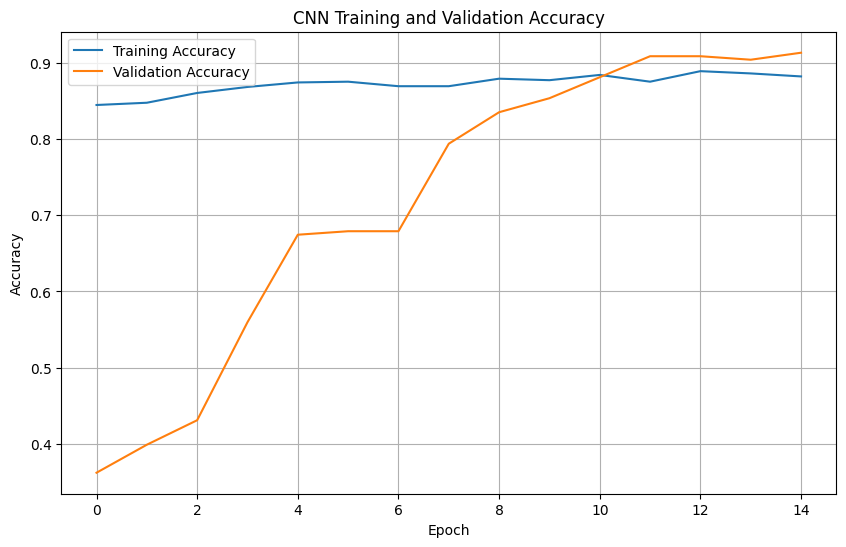

In [55]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(history.history["val_accuracy"],
    label="Validation Accuracy")

plt.title("CNN Training and Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid()

plt.show()

# Plot training loss: LOSS GRAPH

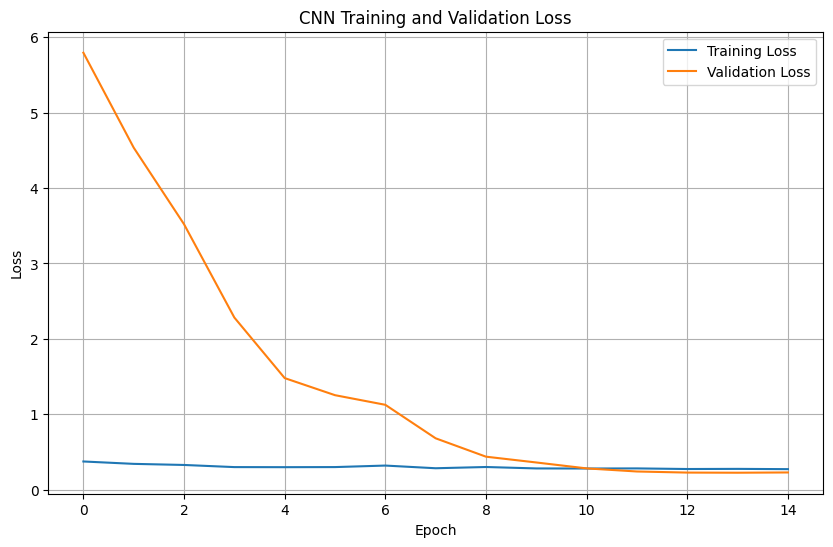

In [56]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["loss"],
    label="Training Loss")

plt.plot(
    history.history["val_loss"],
    label="Validation Loss")

plt.title("CNN Training and Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid()

plt.show()

# Evaluate the model:

In [57]:
test_loss, test_accuracy = model.evaluate(
    test_generator)

print("Test Loss:", test_loss)

print("Test Accuracy:", test_accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 514ms/step - accuracy: 0.8578 - loss: 0.3676
Test Loss: 0.3675876557826996
Test Accuracy: 0.857798159122467


# Generate predictions:

In [ ]:
test_generator.reset()

predictions = model.predict(test_generator)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_generator.classes

class_names = list(test_generator.class_indices.keys())

print("Class names:")
print(class_names)

# Classification report:

In [61]:
print(classification_report(true_classes, predicted_classes, target_names=class_names))

              precision    recall  f1-score   support

      helmet       0.89      0.90      0.89       145
   no_helmet       0.79      0.78      0.79        73

    accuracy                           0.86       218
   macro avg       0.84      0.84      0.84       218
weighted avg       0.86      0.86      0.86       218



# Calculate accuracy, precision, recall and F1:  PERFORMANCE METRICS

In [62]:
accuracy = accuracy_score(true_classes, predicted_classes)

precision = precision_score(true_classes, predicted_classes,average="weighted")

recall = recall_score(true_classes, predicted_classes, average="weighted")

f1 = f1_score(true_classes, predicted_classes, average="weighted")

print(f"Accuracy  : {accuracy:.4f}")

print(f"Precision : {precision:.4f}")

print(f"Recall : {recall:.4f}")

print(f"F1 Score  : {f1:.4f}")

Accuracy  : 0.8578
Precision : 0.8573
Recall : 0.8578
F1 Score  : 0.8576


# CONFUSION MATRIX:

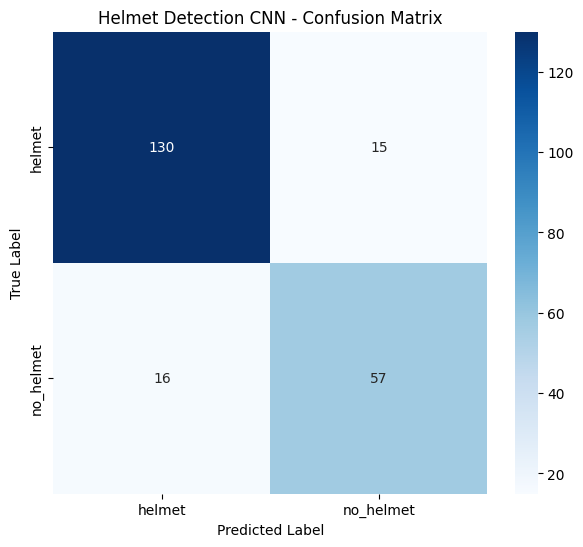

In [63]:
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(7, 6))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names,
            yticklabels=class_names)

plt.title(
    "Helmet Detection CNN - Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.show()

# Save the final model:

In [ ]:
model.save(
    "/content/helmet_detection_cnn.keras")

print("Model saved successfully!")

# Download the trained model:

In [ ]:
from google.colab import files

files.download("/content/helmet_detection_cnn.keras")

# Test one image: (we give the CNN to crop halmet image to check model) :  PREDICT SINGLE IMAGE


In [64]:
def predict_image(image_path):

    image = Image.open(image_path).convert("RGB")

    image = image.resize((IMG_SIZE, IMG_SIZE))

    image_array = np.array(image)

    image_array = (image_array / 255.0)

    image_array = np.expand_dims(image_array, axis=0)

    prediction = model.predict(image_array, verbose=0)[0]

    predicted_index = np.argmax(prediction)

    predicted_class = class_names[predicted_index]

    confidence = prediction[predicted_index]

    plt.figure(figsize=(5, 5))

    plt.imshow(image)

    plt.title(f"{predicted_class} " f"({confidence * 100:.2f}%)")

    plt.axis("off")

    plt.show()

    print("Prediction:", predicted_class)

    print("Confidence:", f"{confidence * 100:.2f}%")

    return predicted_class, confidence

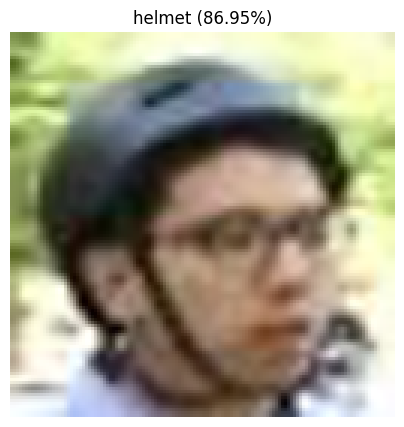

Prediction: helmet
Confidence: 86.95%


('helmet', np.float32(0.86947644))

In [65]:
# Example

test_image = test_generator.filepaths[0]

predict_image(test_image)

# Upload your own image:

Saving image.jpg to image.jpg
Saving halmat image to halmat image
Testing: image.jpg


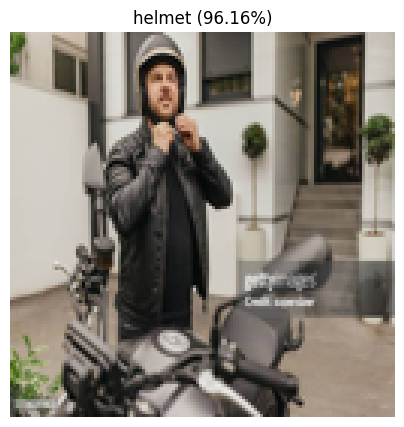

Prediction: helmet
Confidence: 96.16%
Testing: halmat image


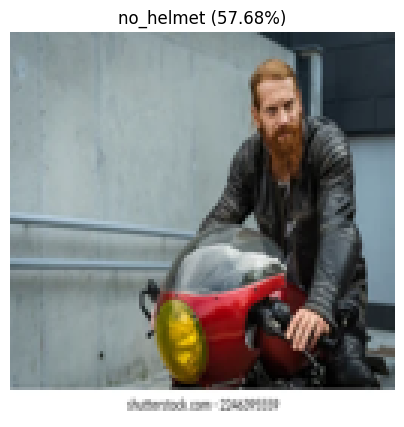

Prediction: no_helmet
Confidence: 57.68%


In [66]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():

    print("Testing:", filename)

    predict_image(filename)

# Test several images:

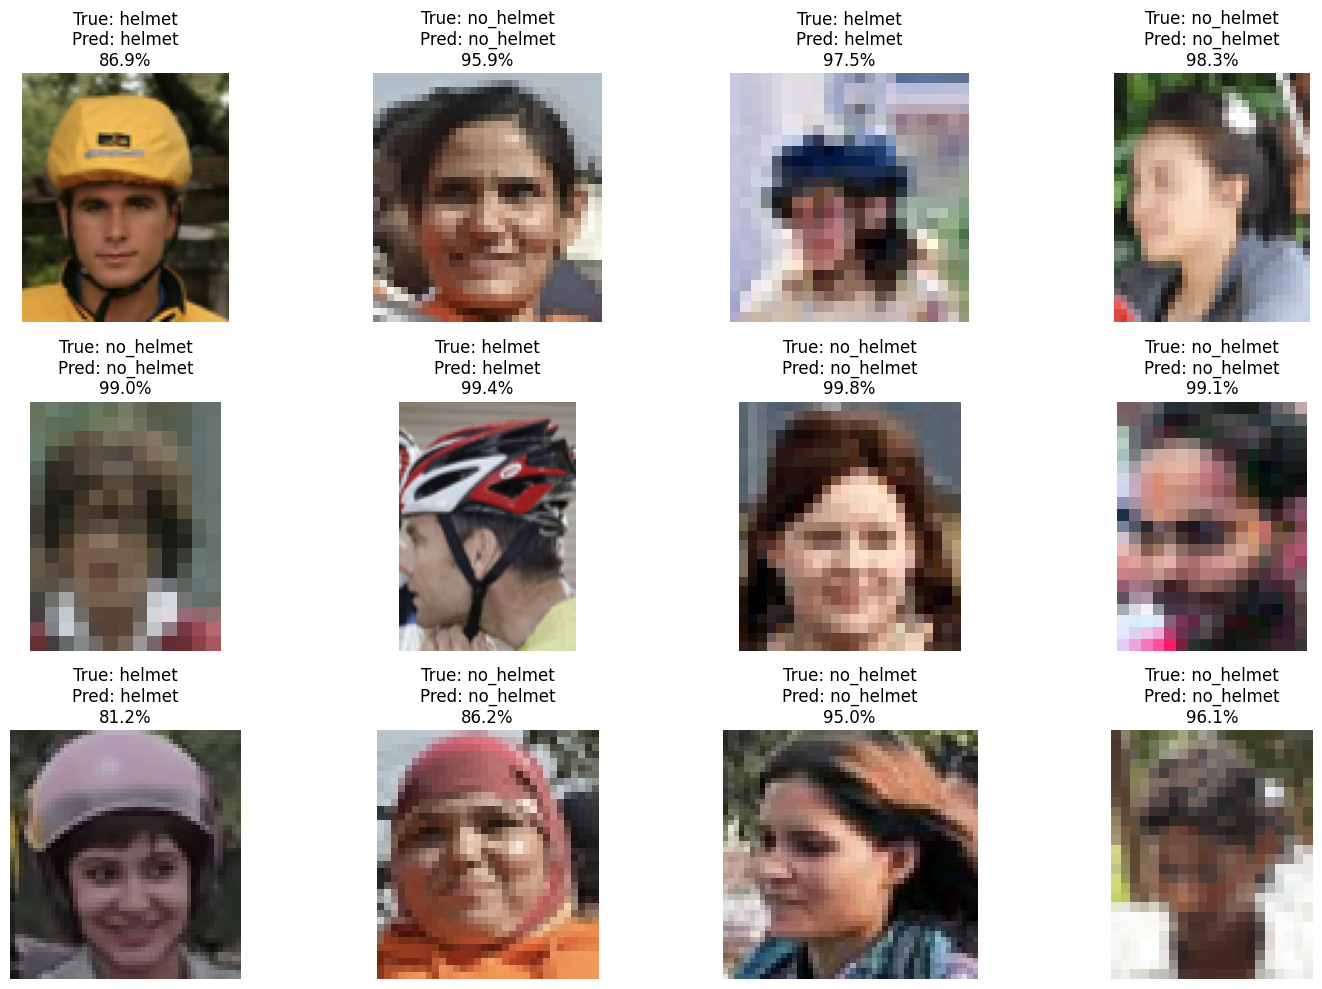

In [67]:
sample_test_images = random.sample(test_generator.filepaths,
                                   min(12, len(test_generator.filepaths)))

plt.figure(figsize=(15, 10))

for i, image_path in enumerate(sample_test_images):

    image = Image.open(image_path).convert("RGB")

    resized = image.resize((IMG_SIZE,IMG_SIZE))

    image_array = np.array(resized) / 255.0

    image_array = np.expand_dims(image_array, axis=0)

    prediction = model.predict(image_array, verbose=0)[0]

    predicted_index = np.argmax(prediction)

    predicted_class = class_names[predicted_index]

    confidence = prediction[predicted_index]

    true_class = os.path.basename(os.path.dirname(image_path))

    plt.subplot(3, 4, i + 1)

    plt.imshow(image)

    plt.title(f"True: {true_class}\n"
        f"Pred: {predicted_class}\n"
        f"{confidence * 100:.1f}%")

    plt.axis("off")

plt.tight_layout()

plt.show()

# Optional: visualize the original bounding boxes:

In [68]:
def show_bounding_boxes(image_path, xml_path):

    image = cv2.imread(image_path)

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    tree = ET.parse(xml_path)

    root = tree.getroot()

    plt.figure(figsize=(12, 8))

    plt.imshow(image)

    for obj in root.findall("object"):

        name = obj.find("name").text

        bbox = obj.find("bndbox")

        xmin = int(float(bbox.find("xmin").text))

        ymin = int(float(bbox.find("ymin").text))

        xmax = int(float(bbox.find("xmax").text))

        ymax = int(float(bbox.find("ymax").text))

        rectangle = plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, fill=False, linewidth=2)

        plt.gca().add_patch(rectangle)

        plt.text(xmin, ymin, name, fontsize=12, backgroundcolor="white")

    plt.axis("off")

    plt.show()

# Example:

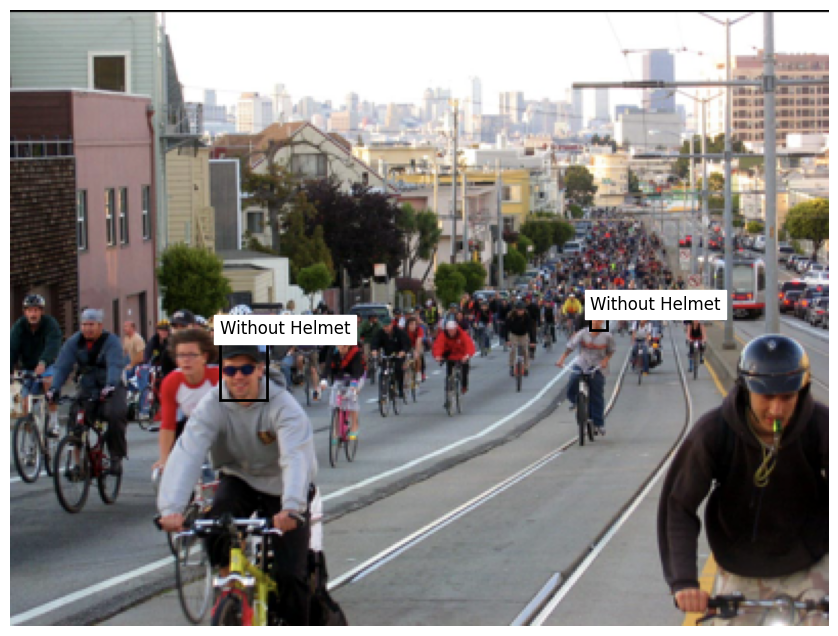

In [69]:
# Find one XML
example_xml = xml_files[0]

tree = ET.parse(example_xml)
root = tree.getroot()

filename = root.find("filename").text

example_image = image_lookup.get(filename)

if example_image is not None:

    show_bounding_boxes(example_image, example_xml)

Complete project structure:

Helmet Detection using CNN
│
├── Dataset
│   ├── Images
│   └── XML Annotations
│
├── Preprocessing
│   ├── Read XML
│   ├── Extract bounding boxes
│   ├── Crop objects
│   └── Assign labels
│
├── Dataset Split
│   ├── Training 70%
│   ├── Validation 15%
│   └── Testing 15%
│
├── CNN
│   ├── Conv2D 32
│   ├── Batch Normalization
│   ├── MaxPooling
│   ├── Conv2D 64
│   ├── Batch Normalization
│   ├── MaxPooling
│   ├── Conv2D 128
│   ├── Batch Normalization
│   ├── MaxPooling
│   ├── Conv2D 256
│   ├── Batch Normalization
│   ├── MaxPooling
│   ├── Flatten
│   ├── Dense 256
│   ├── Dropout
│   └── Output: Helmet / No Helmet
│
├── Training
│
├── Evaluation
│   ├── Accuracy
│   ├── Precision
│   ├── Recall
│   ├── F1 Score
│   ├── Classification Report
│   └── Confusion Matrix
│
└── Prediction
    └── New Image → Helmet / No Helmet